**Import necessary libraries**

In [ ]:

#Import necessary libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_curve, auc
# Import the necessary modules
from tensorflow import keras
from keras import layers
import seaborn as sns
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


**Dataset Preparation**

In [ ]:
# Load the dataset
file_path = '/content/gdrive/MyDrive/dataset_thyroid.csv'  # Update with your file path
df = pd.read_csv(file_path)

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Display columns with missing values
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

print(missing_df)

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

# ============================================================
# 1. LOAD DATASET
# ============================================================

file_path = '/content/gdrive/MyDrive/dataset_thyroid.csv'
df = pd.read_csv(file_path)

# Convert TSH to numeric
df['TSH'] = pd.to_numeric(df['TSH'], errors='coerce')


# ============================================================
# 2. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("Class", axis=1)
y = df["Class"]


# ============================================================
# 3. TRAIN-TEST SPLIT
#    80% Train + Validation
#    20% Test
# ============================================================

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ============================================================
# 4. TRAIN-VALIDATION SPLIT
#    75% of 80% = 60% Train
#    25% of 80% = 20% Validation
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    stratify=y_trainval,
    random_state=42
)


print("Before preprocessing:")
print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


# ============================================================
# 5. DEFINE COLUMNS
# ============================================================

numeric_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

categorical_cols = []

if 'sex' in X_train.columns:
    categorical_cols.append('sex')

if 'referral_source' in X_train.columns:
    categorical_cols.append('referral_source')


# ============================================================
# 6. MISSING VALUE IMPUTATION
#    FIT ONLY ON TRAINING DATA
# ============================================================

# Numeric columns
numeric_imputer = SimpleImputer(strategy='mean')

X_train[numeric_cols] = numeric_imputer.fit_transform(
    X_train[numeric_cols]
)

X_val[numeric_cols] = numeric_imputer.transform(
    X_val[numeric_cols]
)

X_test[numeric_cols] = numeric_imputer.transform(
    X_test[numeric_cols]
)


# Categorical columns
if categorical_cols:

    categorical_imputer = SimpleImputer(strategy='most_frequent')

    X_train[categorical_cols] = categorical_imputer.fit_transform(
        X_train[categorical_cols]
    )

    X_val[categorical_cols] = categorical_imputer.transform(
        X_val[categorical_cols]
    )

    X_test[categorical_cols] = categorical_imputer.transform(
        X_test[categorical_cols]
    )


# ============================================================
# 7. REMOVE OUTLIERS
#    CALCULATE IQR USING TRAINING DATA ONLY
# ============================================================

def get_train_outlier_limits(data, columns):

    limits = {}

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        limits[col] = (lower, upper)

    return limits


outlier_limits = get_train_outlier_limits(
    X_train,
    numeric_cols
)


# Remove outliers ONLY from training data
train_mask = np.ones(len(X_train), dtype=bool)

for col in numeric_cols:

    lower, upper = outlier_limits[col]

    train_mask &= (
        (X_train[col] >= lower) &
        (X_train[col] <= upper)
    )


X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()


# ============================================================
# 8. ENCODE CATEGORICAL VARIABLES
#    FIT ONLY ON TRAINING DATA
# ============================================================

if categorical_cols:

    encoder = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )

    X_train[categorical_cols] = encoder.fit_transform(
        X_train[categorical_cols]
    )

    X_val[categorical_cols] = encoder.transform(
        X_val[categorical_cols]
    )

    X_test[categorical_cols] = encoder.transform(
        X_test[categorical_cols]
    )


# ============================================================
# 9. STANDARDIZATION
#    FIT SCALER ONLY ON TRAINING DATA
# ============================================================

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_val[numeric_cols] = scaler.transform(
    X_val[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)


# ============================================================
# 10. FINAL RESULTS
# ============================================================

print("\nAfter preprocessing:")

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nClass distribution:")
print("Train:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

Before preprocessing:
Train set: (2262, 27)
Validation set: (755, 27)
Test set: (755, 27)

After preprocessing:
Training set: (1790, 27)
Validation set: (755, 27)
Test set: (755, 27)

Class distribution:
Train:
Class
0    1707
1      83
Name: count, dtype: int64

Validation:
Class
0    709
1     46
Name: count, dtype: int64

Test:
Class
0    709
1     46
Name: count, dtype: int64


In [ ]:
# Show first 5 rows
df.head()



,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,referral_source,Class
0,41,F,0,0,0,0,0,0,0,0,...,1.0,2.5,1,125.0,1,1.14,1,109.0,SVHC,0
1,23,F,0,0,0,0,0,0,0,0,...,1.0,2.0,1,102.0,0,1.20,0,124.0,other,0
2,46,M,0,0,0,0,0,0,0,0,...,0.0,1.5,1,109.0,1,0.91,1,120.0,other,0
3,70,F,1,0,0,0,0,0,0,0,...,1.0,1.9,1,175.0,0,1.20,0,124.0,other,0
4,70,F,0,0,0,0,0,0,0,0,...,1.0,1.2,1,61.0,1,0.87,1,70.0,SVI,0


In [ ]:
# Get class distribution
class_counts = df['Class'].value_counts()

# Display nicely
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples")


Class 0: 3541 samples
Class 1: 231 samples


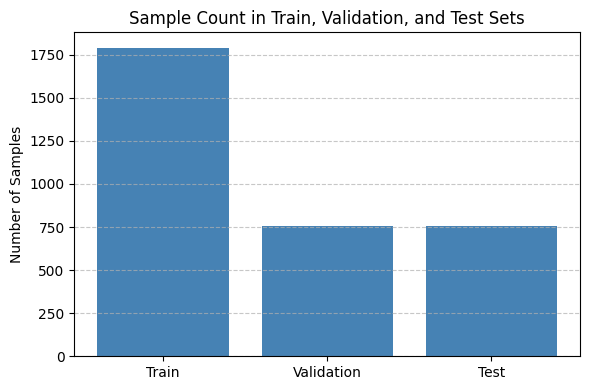

In [ ]:
import matplotlib.pyplot as plt

# Total sample counts
sizes = [len(y_train), len(y_val), len(y_test)]
labels = ['Train', 'Validation', 'Test']

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='steelblue')
plt.ylabel("Number of Samples")
plt.title("Sample Count in Train, Validation, and Test Sets")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# --- Config ---
NUM_NUMERIC = len(numeric_cols) # Updated to match the actual number of numeric columns (6)
CATEGORICAL_VOCAB_SIZES = [2, 5]  # sex, referral_source
EMBED_DIM = 16

# --- Inputs ---
numeric_inputs = Input(shape=(NUM_NUMERIC,), name="numeric_inputs")
cat_inputs = [
    Input(shape=(1,), dtype='int32', name=f"cat_input_{i}") for i in range(len(CATEGORICAL_VOCAB_SIZES))
]

# --- Autoencoder Branch (inline) ---
ae = layers.Dense(32, activation="relu", name="ae_dense_1")(numeric_inputs)
ae = layers.Dense(16, activation="relu", name="ae_dense_2")(ae)

# --- TabTransformer Branch (inline) ---
cat_embeds = [
    layers.Embedding(input_dim=vocab, output_dim=EMBED_DIM, name=f"embed_{i}")(cat_inputs[i])
    for i, vocab in enumerate(CATEGORICAL_VOCAB_SIZES)
]
cat_stack = layers.Concatenate(axis=1, name="cat_stack_concat")(cat_embeds)

x = cat_stack
for i in range(2):
    attn = layers.MultiHeadAttention(num_heads=2, key_dim=EMBED_DIM, name=f"mha_{i}")(x, x)
    x = layers.Add(name=f"add_attn_{i}")([x, attn])
    x = layers.LayerNormalization(name=f"ln_attn_{i}")(x)

    ffn = layers.Dense(EMBED_DIM * 2, activation="relu", name=f"ffn_{i}_1")(x)
    ffn = layers.Dense(EMBED_DIM, name=f"ffn_{i}_2")(ffn)
    x = layers.Add(name=f"add_ffn_{i}")([x, ffn])
    x = layers.LayerNormalization(name=f"ln_ffn_{i}")(x)

tt_out = layers.Flatten(name="flatten_tabtransformer")(x)

# --- Fusion ---
fused = layers.Concatenate(name="fusion_concat")([ae, tt_out])

# --- MLP Classifier ---
mlp = layers.Dense(128, activation="relu", name="mlp_dense_1")(fused)
mlp = layers.BatchNormalization(name="mlp_bn_1")(mlp)
mlp = layers.Dropout(0.3)(mlp)
mlp = layers.Dense(64, activation="relu", name="mlp_dense_2")(mlp)
mlp = layers.BatchNormalization(name="mlp_bn_2")(mlp)
mlp = layers.Dropout(0.3)(mlp)
output = layers.Dense(1, activation="sigmoid", name="output_layer")(mlp)

# --- Final Hybrid Model ---
hybrid_model = Model(inputs=[numeric_inputs] + cat_inputs, outputs=output, name="HybridModel")

In [ ]:
hybrid_model.summary()

Model: "HybridModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_input_0         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_input_1         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_0 (Embedding) │ (None, 1, 16)     │         32 │ cat_input_0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_1 (Embedding) │ (None, 1, 16)     │         80 │ cat_input_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_stack_concat    │ (None, 2, 16)     │          0 │ embed_0[0][0],    │
│ (Concatenate)       │                   │            │ embed_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_0               │ (None, 2, 16)     │      2,160 │ cat_stack_concat… │
│ (MultiHeadAttentio… │                   │            │ cat_stack_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_attn_0 (Add)    │ (None, 2, 16)     │          0 │ cat_stack_concat… │
│                     │                   │            │ mha_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn_0           │ (None, 2, 16)     │         32 │ add_attn_0[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_0_1 (Dense)     │ (None, 2, 32)     │        544 │ ln_attn_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_0_2 (Dense)     │ (None, 2, 16)     │        528 │ ffn_0_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_ffn_0 (Add)     │ (None, 2, 16)     │          0 │ ln_attn_0[0][0],  │
│                     │                   │            │ ffn_0_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_ffn_0            │ (None, 2, 16)     │         32 │ add_ffn_0[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_1               │ (None, 2, 16)     │      2,160 │ ln_ffn_0[0][0],   │
│ (MultiHeadAttentio… │                   │            │ ln_ffn_0[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_attn_1 (Add)    │ (None, 2, 16)     │          0 │ ln_ffn_0[0][0],   │
│                     │                   │            │ mha_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn_1           │ (None, 2, 16)     │         32 │ add_attn_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_1_1 (Dense)     │ (None, 2, 32)     │        544 │ ln_attn_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_1_2 (Dense)     │ (None, 2, 16)     │        528 │ ffn_1_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_inputs      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_ffn_1 (Add)     │ (None, 2, 16)     │          0 │ ln_attn_1[0][0],

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,433 (87.63 KB)

 Non-trainable params: 384 (1.50 KB)

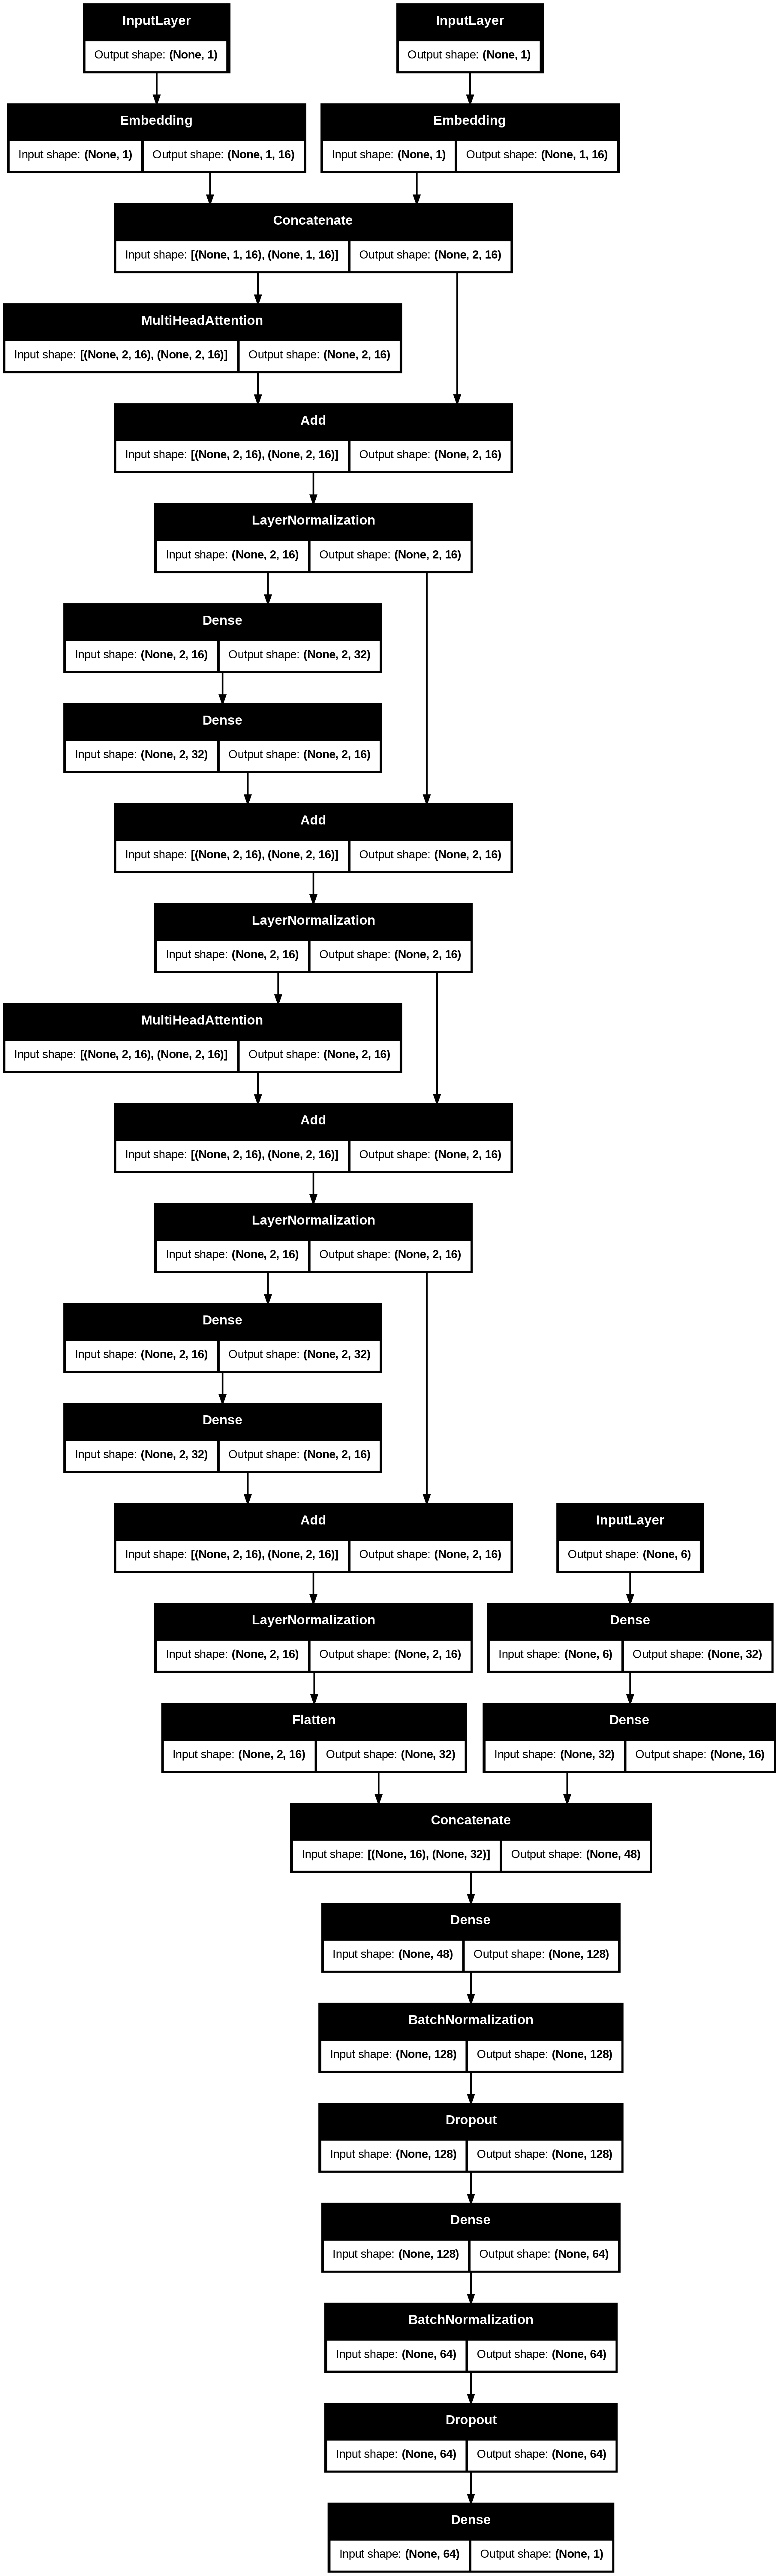

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(hybrid_model, to_file='model.png', show_shapes=True,expand_nested=True)

**Model Compilation and Training**

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

#  Calculate class weights using ONLY the training data

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)




Class weights: {0: np.float64(0.5243116578793204), 1: np.float64(10.783132530120483)}


In [ ]:

# Compile the model

hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)



model_checkpoint = ModelCheckpoint(
    "best_hybrid_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

# Optional early stopping

early_stop = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


# Prepare inputs

X_train_inputs = (
    [X_train[numeric_cols]]
    + [X_train[[col]] for col in categorical_cols]
)

X_val_inputs = (
    [X_val[numeric_cols]]
    + [X_val[[col]] for col in categorical_cols]
)



# Train the model
#
history = hybrid_model.fit(
    X_train_inputs,
    y_train,
    validation_data=(X_val_inputs, y_val),
    epochs=55,
    batch_size=64,
    #class_weight=class_weight_dict,

    # Learning-rate scheduling + checkpoint + early stopping
    callbacks=[
        lr_scheduler,
        model_checkpoint
    ],

    verbose=1
)

Epoch 1/55
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.5642 - loss: 0.7986 - val_accuracy: 0.4132 - val_loss: 0.7655 - learning_rate: 0.0010
Epoch 1: val_loss improved from inf to 0.76550, saving model to best_hybrid_model.keras
Epoch 1: finished saving model to best_hybrid_model.keras
Epoch 2/55
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6922 - loss: 0.6046 - val_accuracy: 0.7974 - val_loss: 0.7115 - learning_rate: 0.0010
Epoch 2: val_loss improved from 0.76550 to 0.71150, saving model to best_hybrid_model.keras
Epoch 2: finished saving model to best_hybrid_model.keras
Epoch 3/55
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7704 - loss: 0.5136 - val_accuracy: 0.8927 - val_loss: 0.6213 - learning_rate: 0.0010
Epoch 3: val_loss improved from 0.71150 to 0.62130, saving model to best_hybrid_model.keras
Epoch 3: finished saving model to best_hybrid_model.keras
Epoch 4/55
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8425 - loss: 0.4134 - val_accuracy:

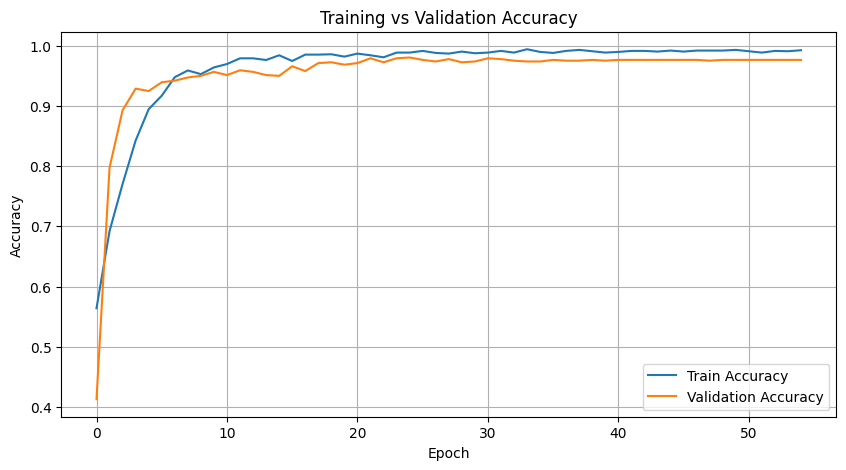

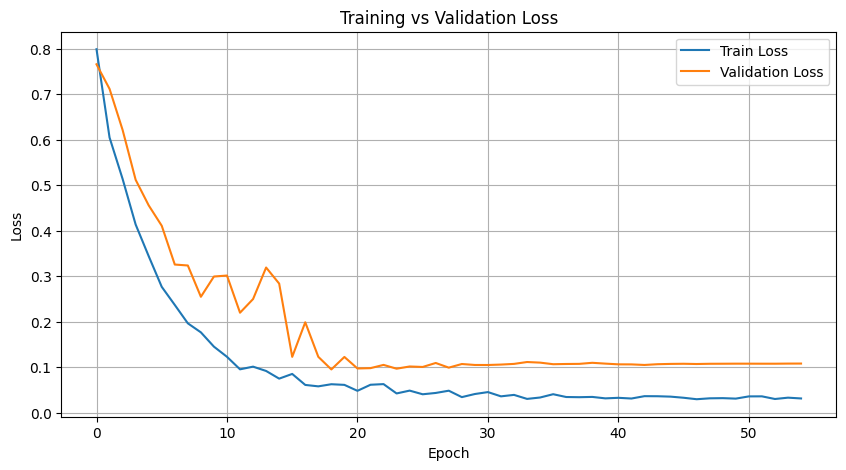

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have a trained Keras history object
# Example: history = model.fit(...)

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


**Model Evaluation**

In [ ]:
X_test_inputs = [X_test[numeric_cols]] + [X_test[[col]] for col in categorical_cols]
test_loss, test_accuracy = hybrid_model.evaluate(X_test_inputs, y_test)
print(f"Test Accuracy: {test_accuracy:.4f} | Test Loss: {test_loss:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9788 - loss: 0.1294
Test Accuracy: 0.9788 | Test Loss: 0.1294


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (hybrid_model.predict(X_test_inputs) > 0.5).astype("int32")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred,digits= 4))


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
[[701   8]
 [  8  38]]
              precision    recall  f1-score   support

           0     0.9887    0.9887    0.9887       709
           1     0.8261    0.8261    0.8261        46

    accuracy                         0.9788       755
   macro avg     0.9074    0.9074    0.9074       755
weighted avg     0.9788    0.9788    0.9788       755



In [ ]:
y_pred_classes = (hybrid_model.predict(X_test_inputs) > 0.5).astype("int32")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


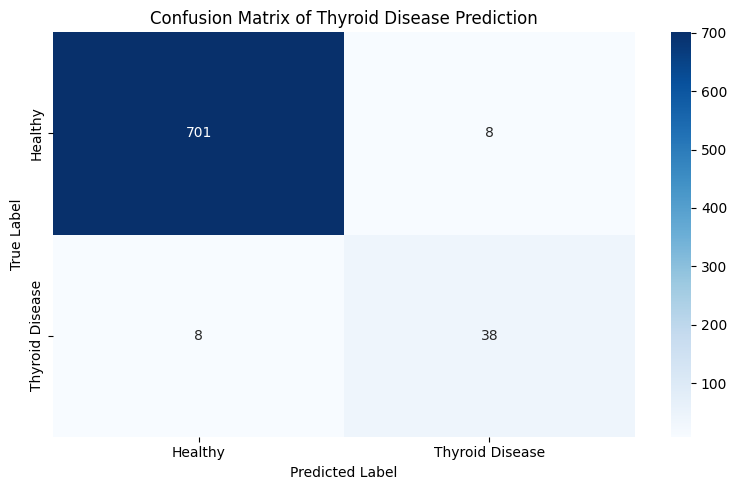

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred_classes are defined
# y_pred_classes = (model.predict(X_test_inputs) > 0.5).astype("int32")

# Define custom labels
Index = ["Healthy", "Thyroid Disease"]
Columns = ["Healthy", "Thyroid Disease"]

# Create the confusion matrix DataFrame
cm = pd.DataFrame(
    data=confusion_matrix(y_test, y_pred_classes),
    index=Index,
    columns=Columns
)

# Plot
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of Thyroid Disease Prediction")
plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


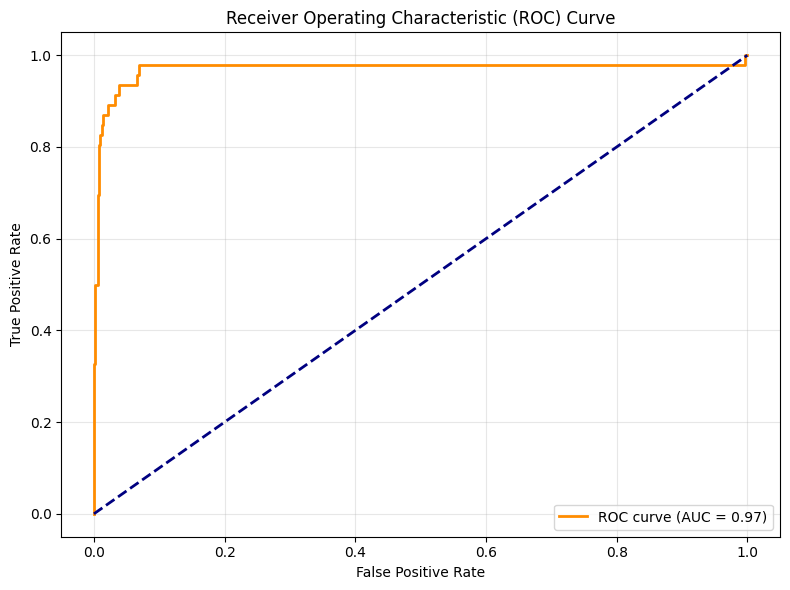

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Predict probabilities
y_probs = hybrid_model.predict(X_test_inputs).ravel()  # get probabilities for class 1

# Step 2: Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Step 3: Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


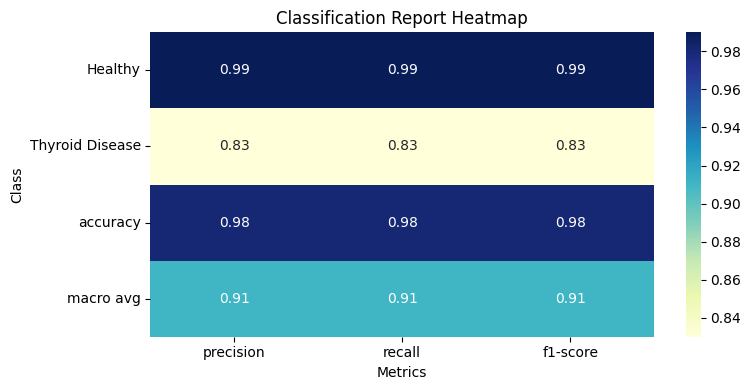

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# Generate report as a dictionary
# Use 'y_test' instead of 'y_true_classes'
report_dict = classification_report(y_test, y_pred_classes, target_names=["Healthy", "Thyroid Disease"], output_dict=True)

# Convert to DataFrame and round values
report_df = pd.DataFrame(report_dict).T.round(2)

# Plot heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="YlGnBu", cbar=True)
plt.title("Classification Report Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Class")
plt.tight_layout()
plt.show()